In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
df = pd.read_csv(r"C:\Users\yashd\Downloads\flight_price\Clean_Dataset.csv")
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.shape

(300153, 12)

In [4]:
df = df.drop('Unnamed: 0', axis =1 )

In [5]:
df.shape

(300153, 11)

In [6]:
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [8]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [9]:
df['airline'].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [10]:
airline_price = df.groupby('airline')['price'].mean().sort_values(ascending=False)

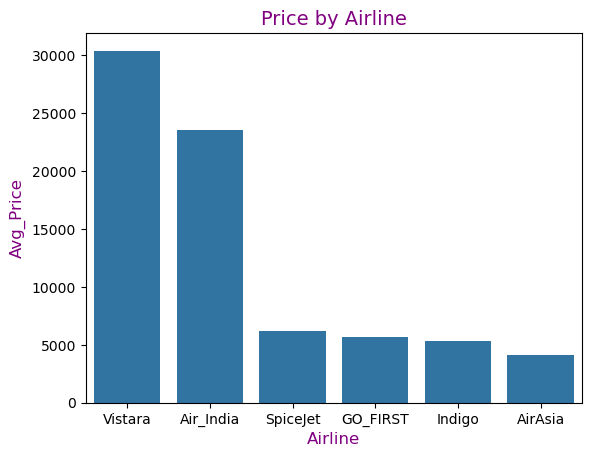

In [11]:
sns.barplot(x=airline_price.index, y=airline_price.values)
plt.xlabel('Airline', fontsize=12, color='purple')
plt.ylabel('Avg_Price', fontsize=12, color='purple')
plt.title('Price by Airline', fontsize=14, color='purple')
plt.show()

In [12]:
class_count = df['class'].value_counts()

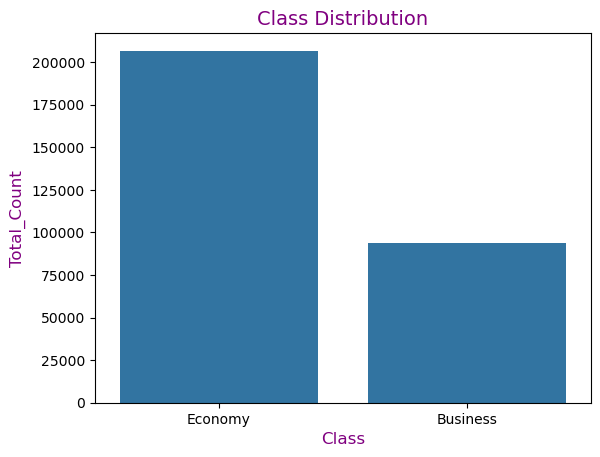

In [13]:
sns.barplot(x=class_count.index, y=class_count.values)
plt.xlabel('Class', fontsize=12, color='purple')
plt.ylabel('Total_Count', fontsize=12,color='purple')
plt.title('Class Distribution', fontsize=14, color='purple')
plt.show()

In [14]:
class_price = df.groupby('class')['price'].mean().sort_values(ascending = False)

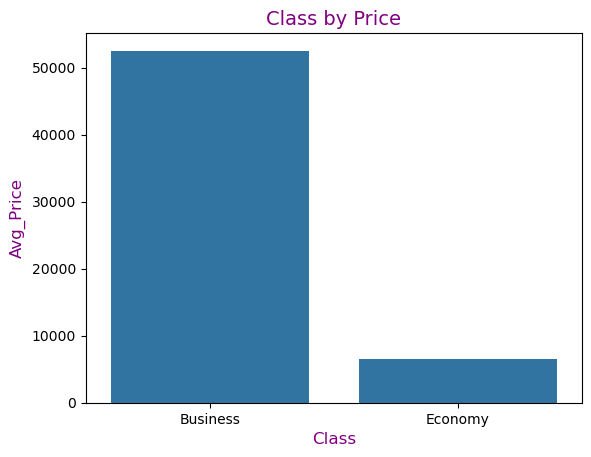

In [15]:
sns.barplot(x=class_price.index, y=class_price.values)
plt.title('Class by Price', fontsize=14, color='purple')
plt.xlabel('Class', fontsize=12, color='purple')
plt.ylabel('Avg_Price', fontsize=12,color='purple')
plt.show()

In [16]:
stops_price = df.groupby('stops')['price'].mean().sort_values(ascending=False)

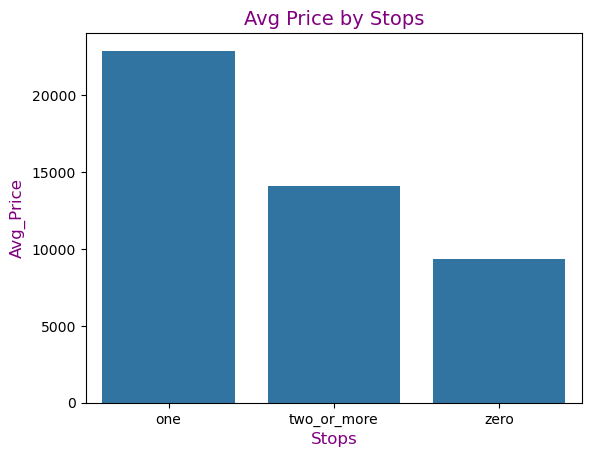

In [17]:
sns.barplot(x=stops_price.index, y=stops_price.values)
plt.xlabel("Stops",fontsize=12, color='purple')
plt.ylabel('Avg_Price', fontsize=12, color='purple')
plt.title('Avg Price by Stops', fontsize=14, color='purple')
plt.show()

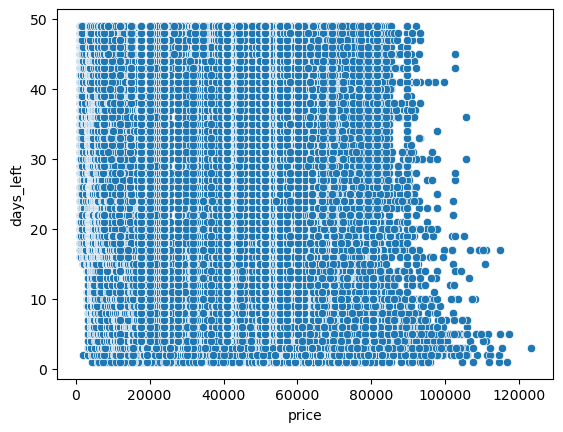

In [18]:
sns.scatterplot(x=df['price'],y=df['days_left'])
plt.show()

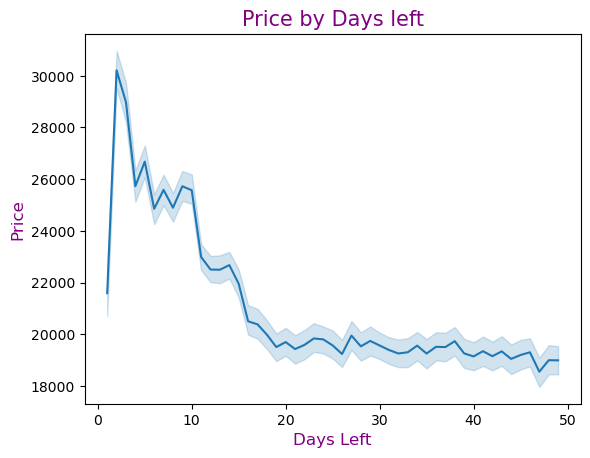

In [19]:
sns.lineplot(x='days_left',y='price',data=df)
plt.title('Price by Days left', fontsize=15, color='purple')
plt.xlabel('Days Left', fontsize=12, color='purple')
plt.ylabel('Price', fontsize=12, color='purple')
plt.show()

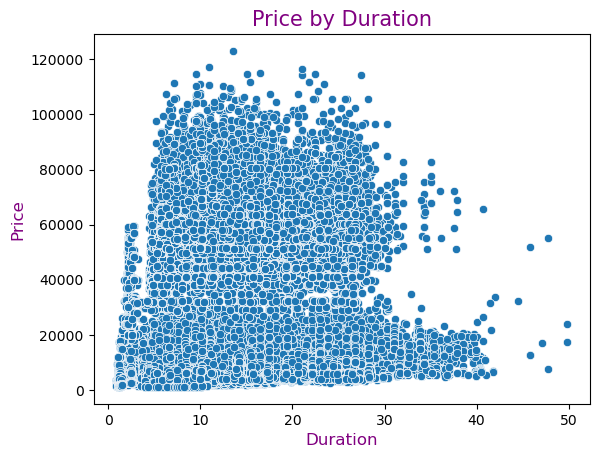

In [20]:
sns.scatterplot(x='duration',y='price',data=df)
plt.title('Price by Duration', fontsize=15, color='purple')
plt.xlabel('Duration', fontsize=12, color='purple')
plt.ylabel('Price', fontsize=12, color='purple')
plt.show()

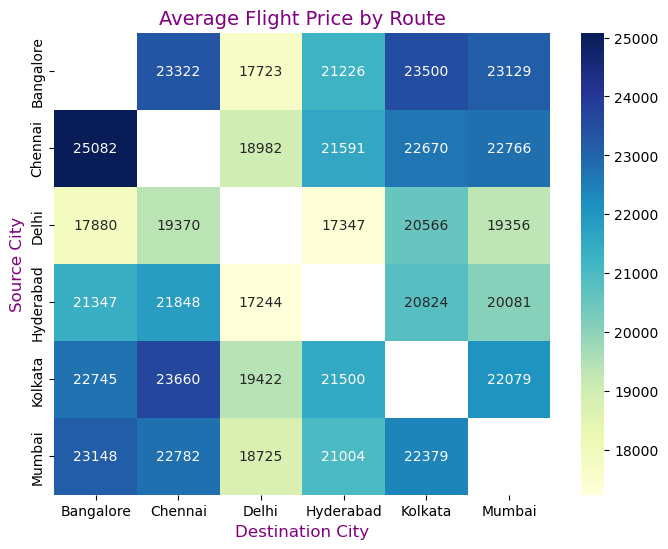

In [21]:
route_prices = df.pivot_table(values='price', index='source_city', columns='destination_city', aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(route_prices, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Flight Price by Route",color='purple', fontsize=14)
plt.xlabel('Destination City', color='purple', fontsize=12)
plt.ylabel('Source City',color='purple', fontsize=12)
plt.show()

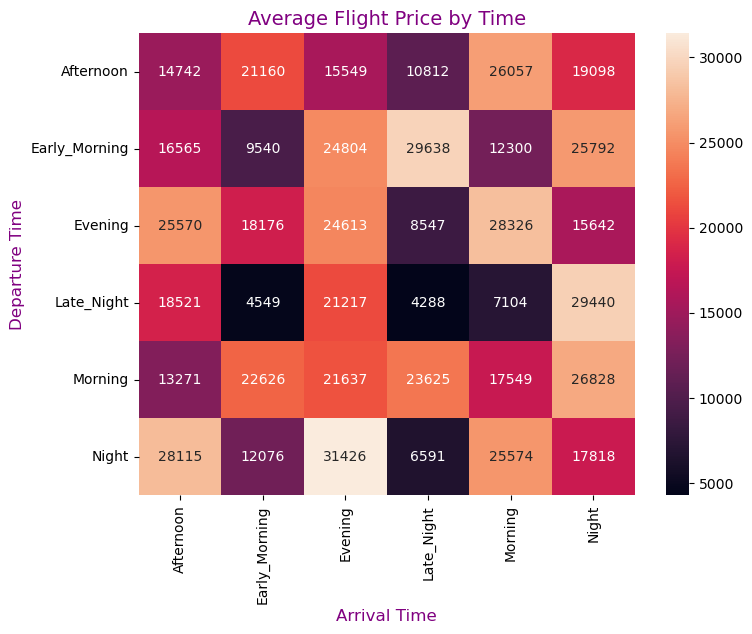

In [22]:
reach_price = df.pivot_table(index='departure_time',values ='price',columns='arrival_time',aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(reach_price, annot = True, fmt= '.0f')
plt.title('Average Flight Price by Time',fontsize=14,color='purple')
plt.xlabel('Arrival Time', fontsize=12, color='purple')
plt.ylabel('Departure Time', fontsize=12,color='purple')
plt.show()

In [23]:
df = df.drop(['flight'], axis=1)

In [95]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [26]:
x=df.drop('price',axis=1)
y=df['price']

x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
cat_col = df.select_dtypes('object').columns.to_list()

In [28]:
preprocessing = ColumnTransformer(transformers=
                                  [('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'),cat_col)],remainder='passthrough',
                                  force_int_remainder_cols = False)

## Linear Regression

In [30]:
lr_model = Pipeline(steps=
                    [('preprocessing', preprocessing),
                     ('lr',LinearRegression())])

lr_model.fit(x_train, y_train)  

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('lr', LinearRegression())])

In [31]:
lr_model.score(x_test,y_test)

0.9113047134121911

In [32]:
lr_model.score(x_train, y_train)

0.911492575818877

In [33]:
scores = cross_val_score(lr_model, x_train, y_train, cv=5)
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.911468026420758


In [103]:
mean_absolute_error(y_test, lr_model.predict(x_test))

4553.346288550987

## Decision Tree Regressor

In [35]:
dtr_model = Pipeline(steps=
                     [('preprocessing',preprocessing),
                      ('dtr',DecisionTreeRegressor(max_depth=5))])

dtr_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('dtr', DecisionTreeRegressor(max_depth=5))])

In [36]:
dtr_model.score(x_test, y_test)

0.9414117827992418

In [37]:
dtr_model.score(x_train, y_train)

0.9425362479042969

In [38]:
scores = cross_val_score(dtr_model, x_train, y_train, cv=5)
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.9425006022219199


In [101]:
mean_absolute_error(y_test, dtr_model.predict(x_test))

3223.070040097254

## Random Forest Regressor

In [40]:
rfr_model = Pipeline(steps=
                     [('preprocessing', preprocessing),
                      ('rfr',RandomForestRegressor(n_estimators=100, max_depth = 5))])

rfr_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('rfr', RandomForestRegressor(max_depth=5))])

In [41]:
rfr_model.score(x_test, y_test)

0.9416867801151247

In [42]:
rfr_model.score(x_train, y_train)

0.9428201915755415

In [43]:
scores = cross_val_score(rfr_model, x_train, y_train, cv=5)
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.9429047594463735


In [99]:
mean_absolute_error(y_test, rfr_model.predict(x_test))

3212.655842678418

In [87]:
xgBoost_model = Pipeline(steps=
                         [('preprocessing', preprocessing),
                          ('xgboost', XGBRegressor(n_estimators=100, 
                    learning_rate=0.1,
                    max_depth=6,
                    random_state=42))])

xgBoost_model.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['airline', 'source_city',
                                                   'departure_time', 'stops',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('xgboost',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsam...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [89]:
xgBoost_model.score(x_train, y_train)

0.9692214727401733

In [91]:
xgBoost_model.score(x_test, y_test)

0.9676152467727661

In [97]:
mean_absolute_error(y_test, xgBoost_model.predict(x_test))

2348.031964801991

In [120]:
results = {
    'Model': ['Linear Regression', 'Decision Tree', 
              'Random Forest', 'XGBoost'],
    'R2 Score': [0.91, 0.94, 0.94, 0.96],  # apne actual scores daalo
    'MAE': [4553.3,3223,3212.6,2348]
}

pd.DataFrame(results).sort_values('R2 Score', ascending=False)

,Model,R2 Score,MAE
3,XGBoost,0.96,2348.0
1,Decision Tree,0.94,3223.0
2,Random Forest,0.94,3212.6
0,Linear Regression,0.91,4553.3


In [111]:
import joblib
joblib.dump(xgBoost_model, "flight_model.pkl", compress = 3)

['flight_model.pkl']